In [1]:
!pip install datacleaner

  Preparing metadata (setup.py) ... done
  Created wheel for datacleaner: filename=datacleaner-0.1.5-py3-none-any.whl size=7408 sha256=0224b7ee06dc2fb4aa28654674d48da659484fabcc61e60760a9a4c6d28f920d
  Stored in directory: /root/.cache/pip/wheels/8f/bc/5b/f7ca5772f61851334a8580f3ede175b92a7122eef3464e2b3d
Successfully built datacleaner


In [2]:
!pip install fasteda -q

In [3]:
#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import datacleaner
from datacleaner import autoclean
from fasteda import fast_eda

import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [4]:
train = pd.read_csv("/kaggle/input/titanic/train.csv")
test = pd.read_csv("/kaggle/input/titanic/test.csv")
gender_submission = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")

## Data Inspection

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [8]:
print(train.shape, test.shape)

(891, 12) (418, 11)


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data Cleaning and Preprocessing

In [11]:
train_clean = autoclean(train)
train_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,47,2


## Exploratory Data Analysis

DataFrame Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2


DataFrame Tail:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,413,0,28.0,1,2,675,23.45,47,2
889,890,1,1,81,1,26.0,0,0,8,30.00,60,0
890,891,0,3,220,1,32.0,0,0,466,7.75,47,1


----------------------------------------------------------------------------------------------------
Missing values:


,0


----------------------------------------------------------------------------------------------------
Shape of DataFrame:

(891, 12)

----------------------------------------------------------------------------------------------------
DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    int64  
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    int64  
 11  Embarked     891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB
----

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
PassengerId,891,446,446,257.354,1,223.5,446,668.5,891,0.000000,-1.200003
Survived,891,0.384,0,0.487,0,0,0,1,1,0.477717,-1.771786
Pclass,891,2.309,3,0.836,1,2,3,3,3,-0.629486,-1.279570
Name,891,445,445,257.354,0,222.5,445,667.5,890,0.000000,-1.200003
Sex,891,0.648,1,0.478,0,0,1,1,1,-0.617878,-1.618226
Age,891,29.362,28,13.02,0.42,22,28,35,80,0.509385,0.981576
SibSp,891,0.523,0,1.103,0,0,0,1,8,3.689128,17.773512
Parch,891,0.382,0,0.806,0,0,0,0,6,2.744487,9.716613
Ticket,891,338.529,337,200.851,0,158.5,337,519.5,680,0.000245,-1.277781
Fare,891,32.204,14.454,49.693,0,7.91,14.454,31,512.329,4.779253,33.204289


----------------------------------------------------------------------------------------------------
DataFrame Correlation:



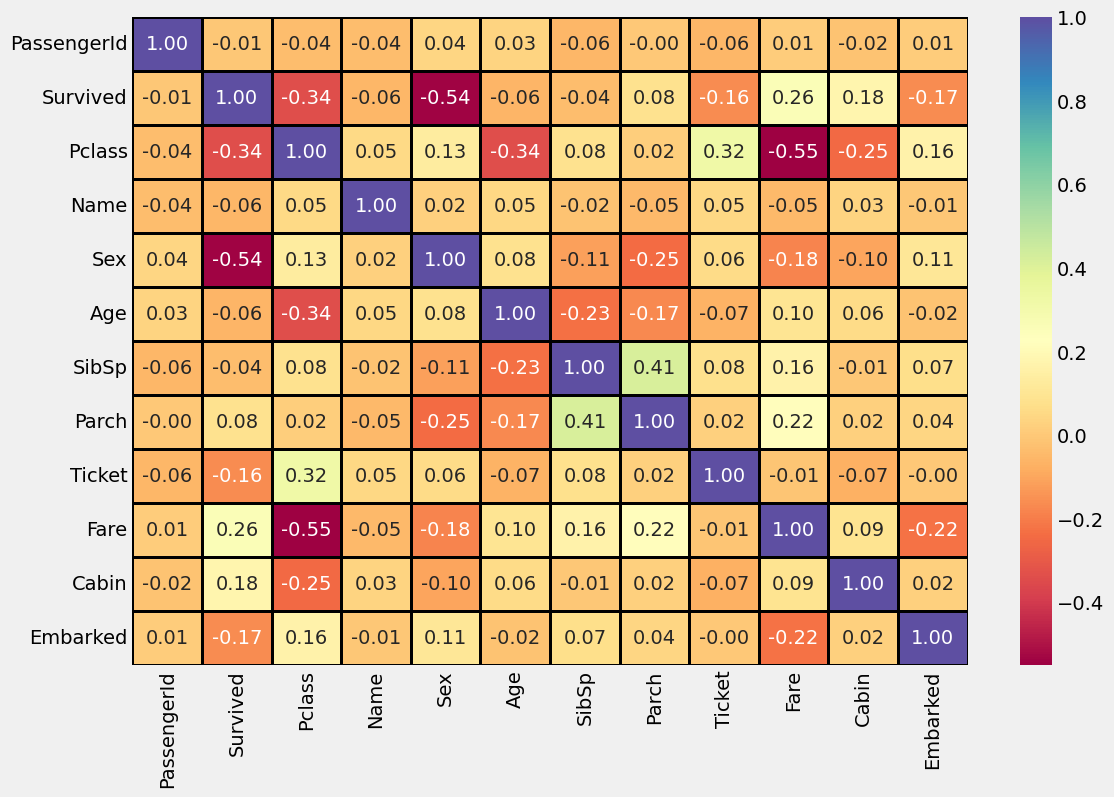

----------------------------------------------------------------------------------------------------
DataFrame Pairplot:



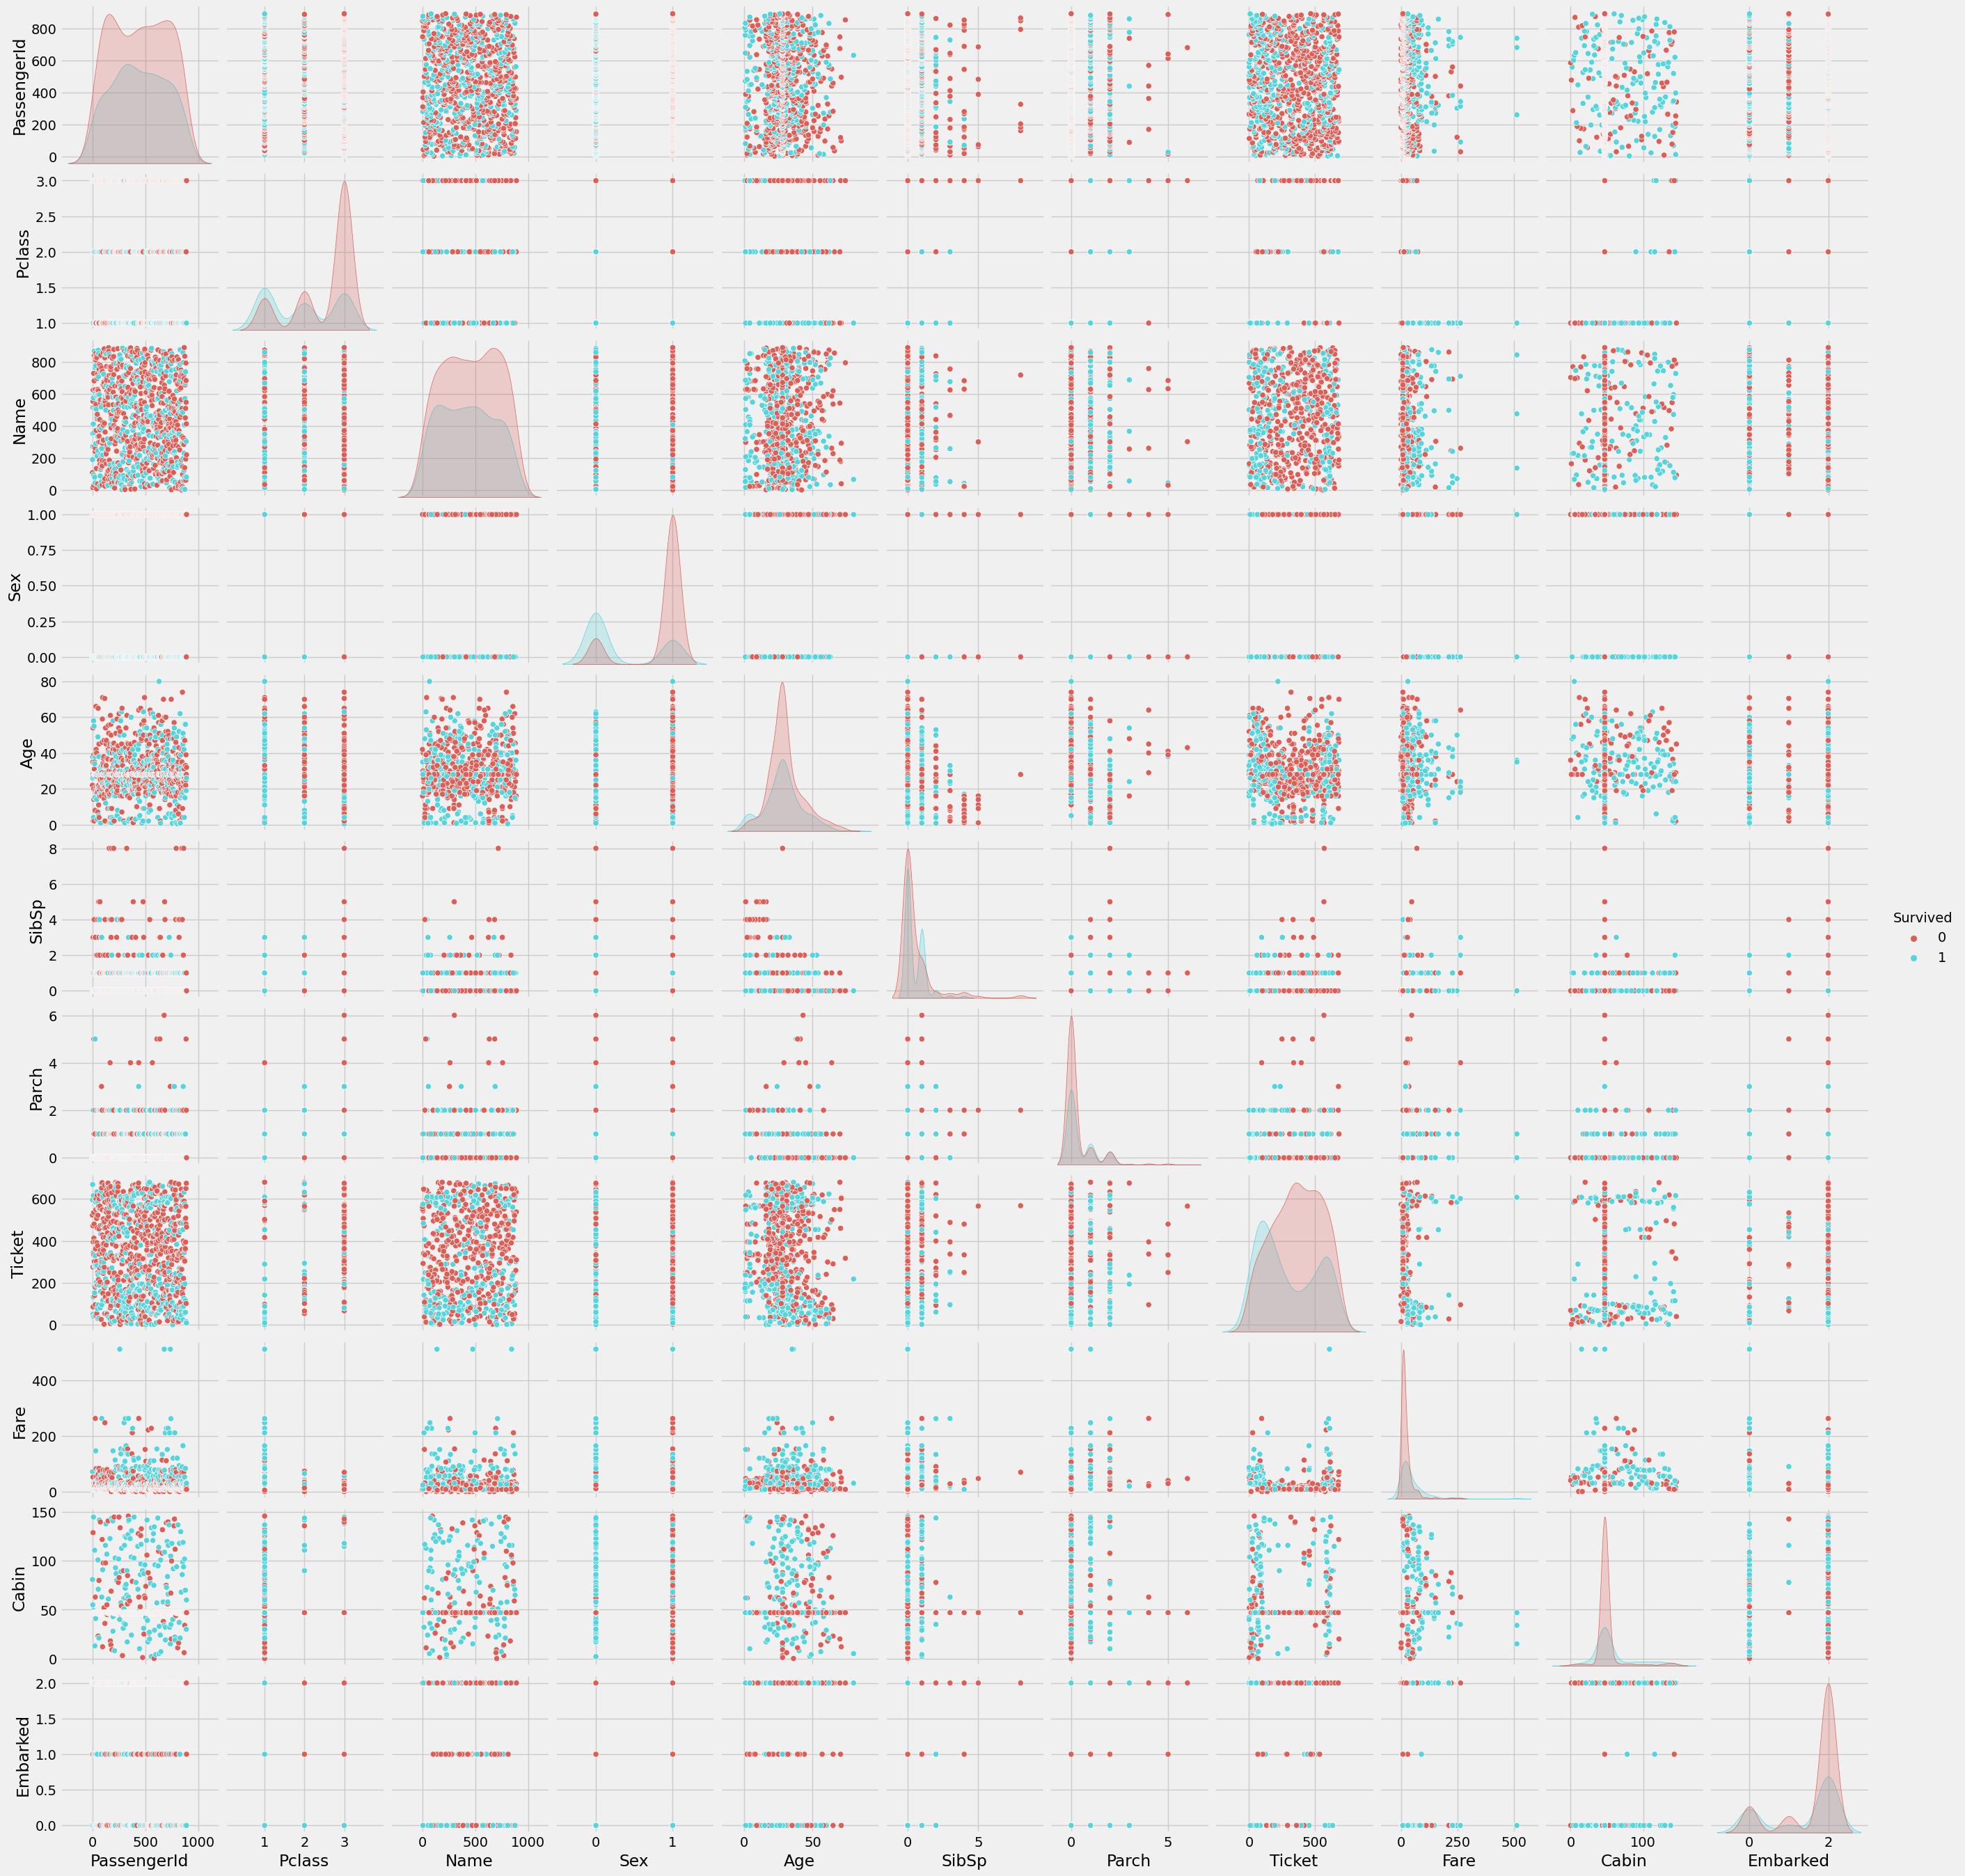

----------------------------------------------------------------------------------------------------
Histogram(s) & Boxplot(s):



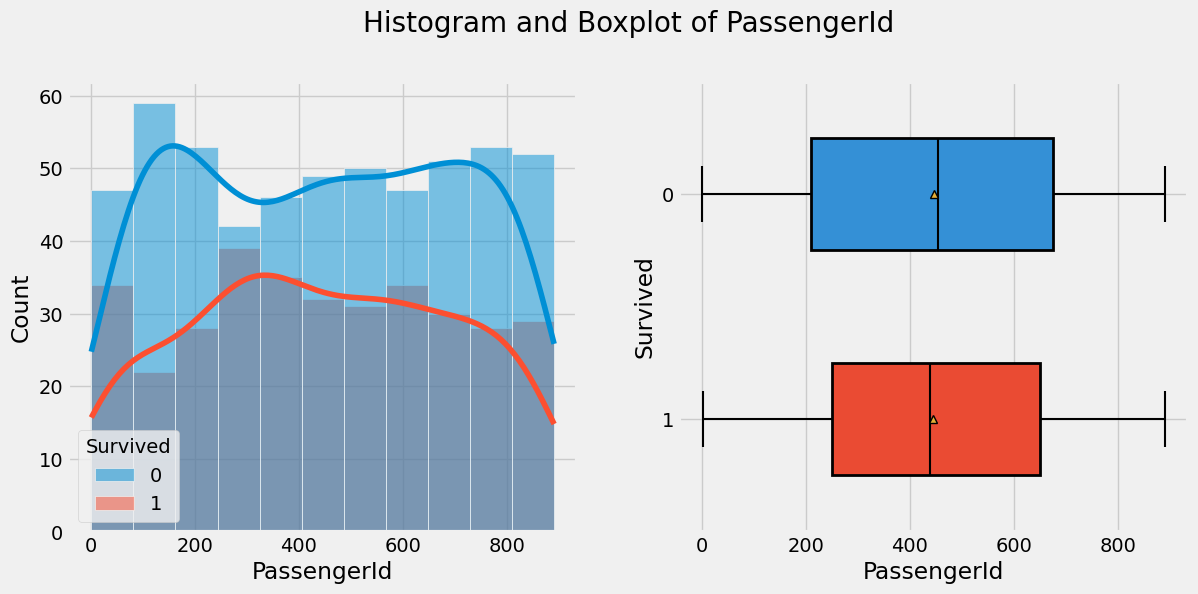

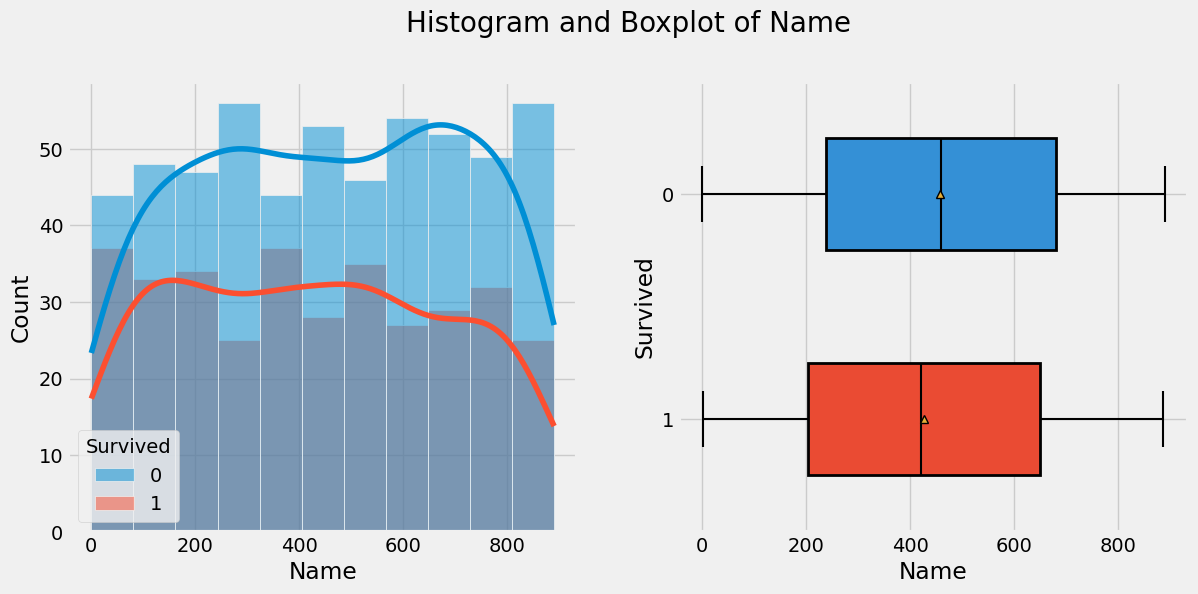

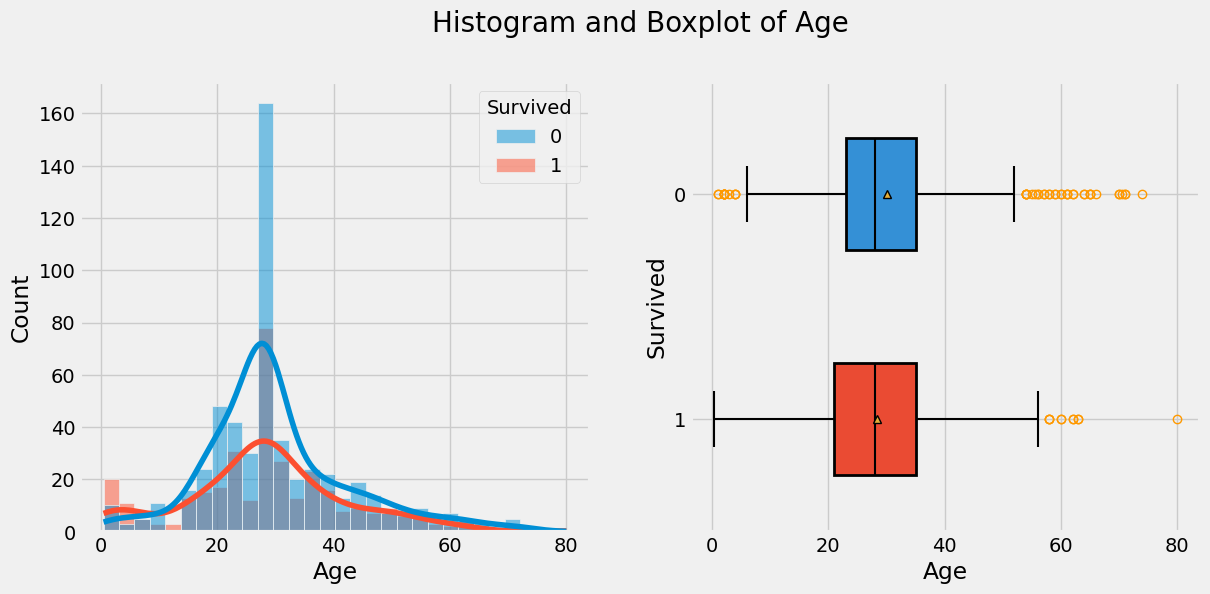

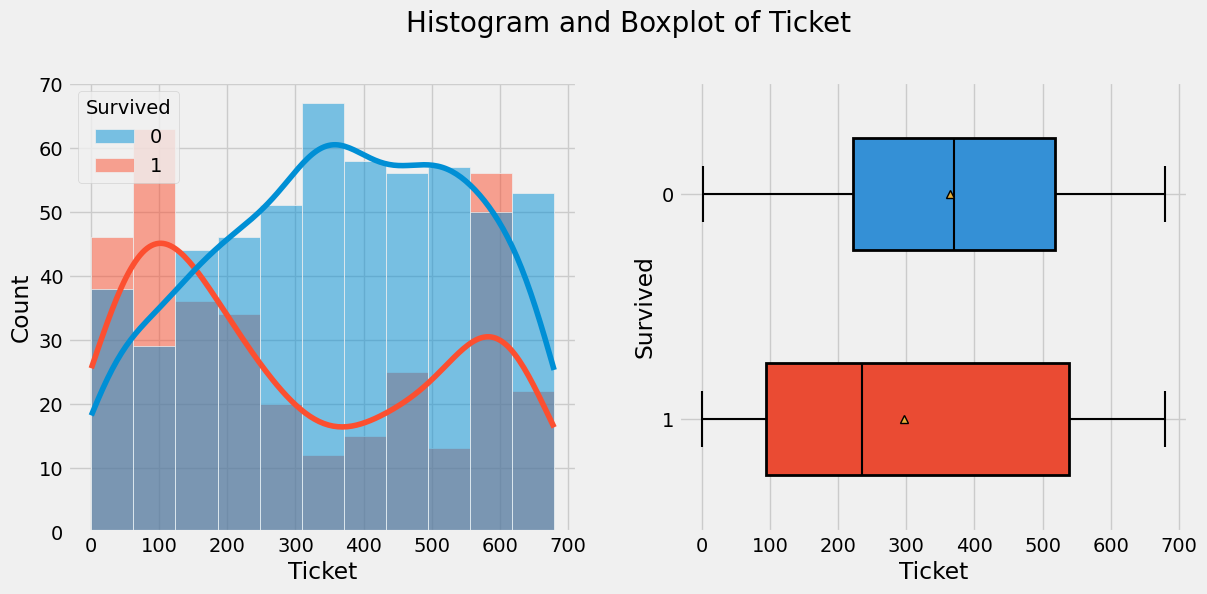

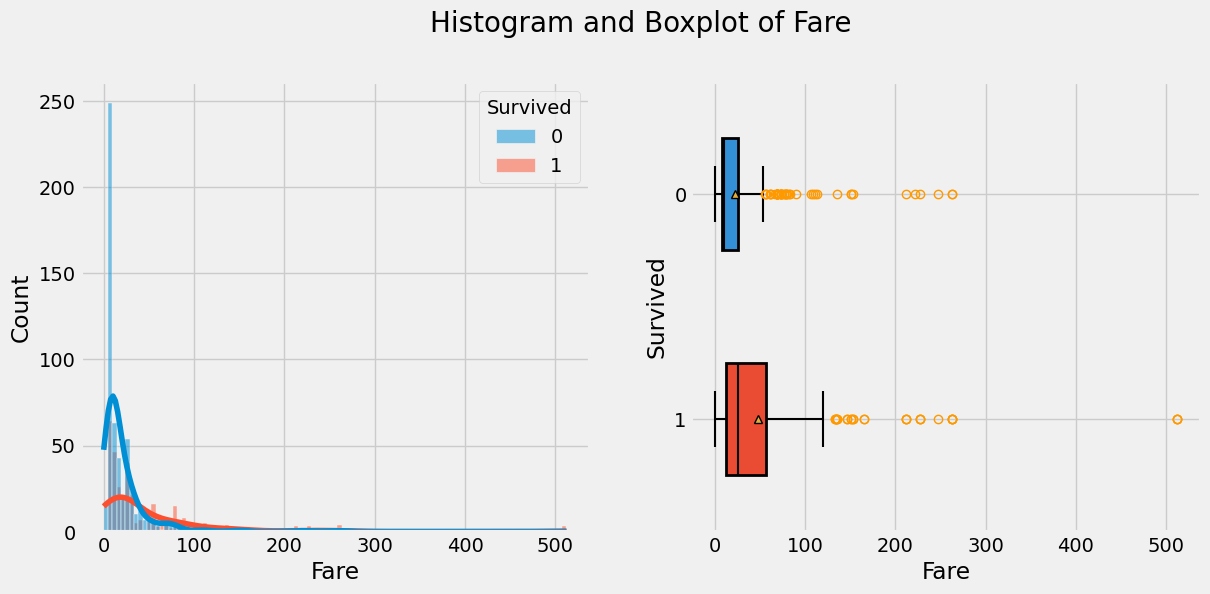

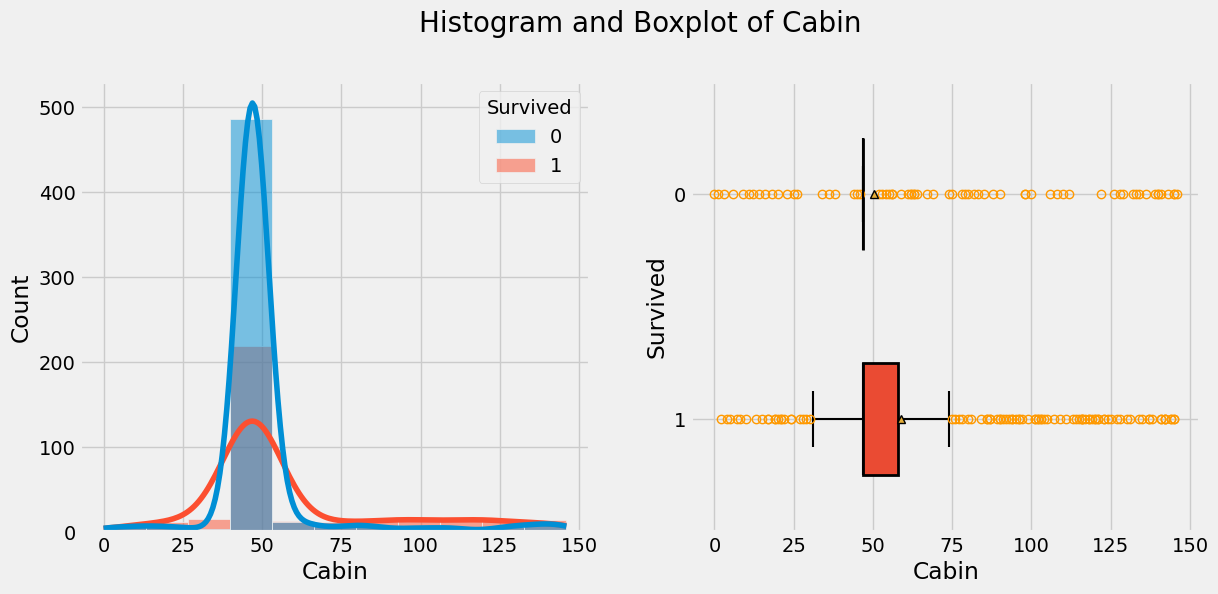

----------------------------------------------------------------------------------------------------
Countplot(s):



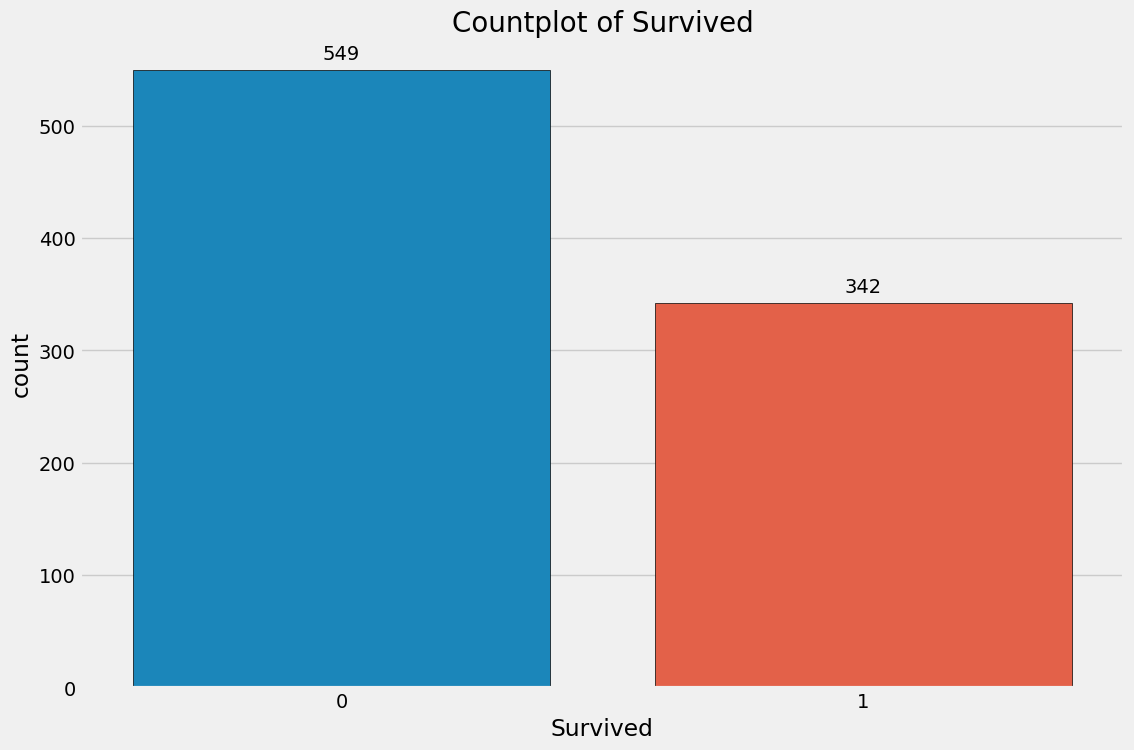

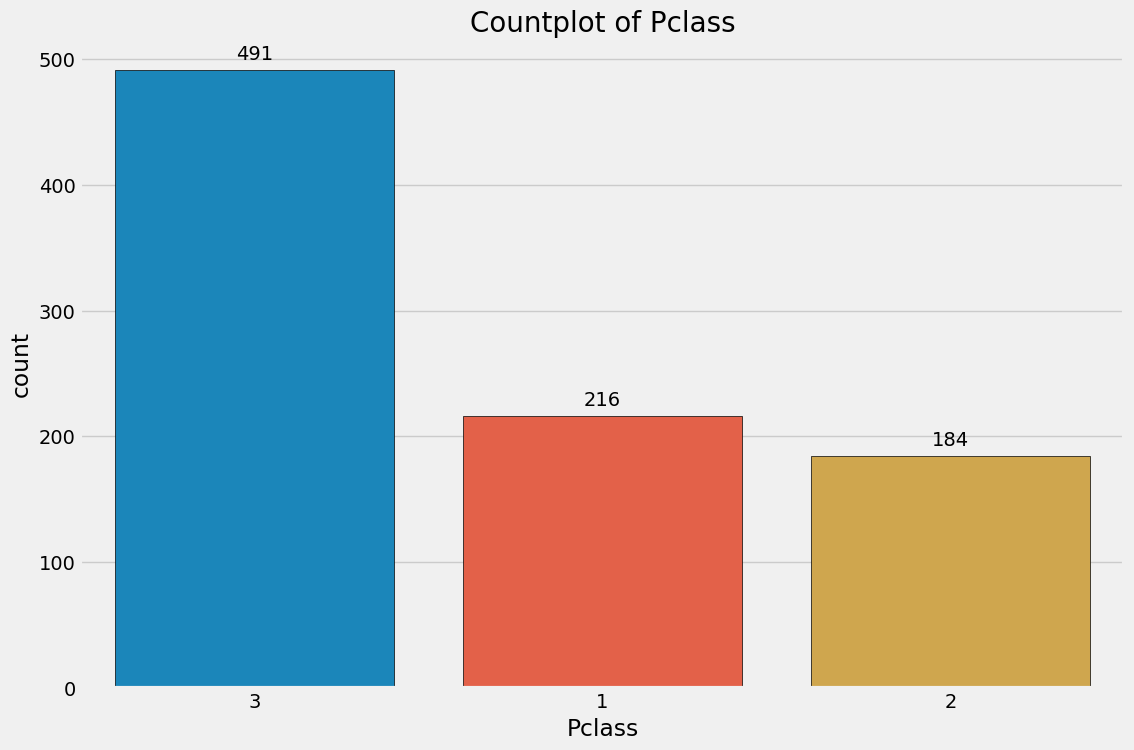

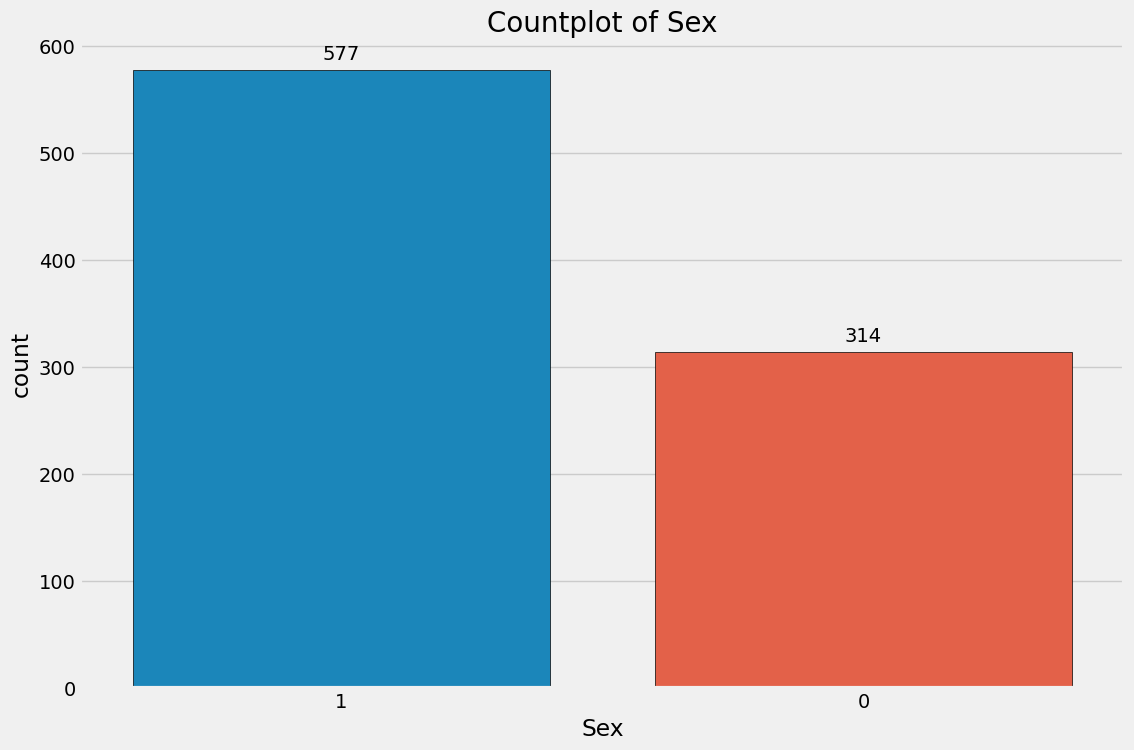

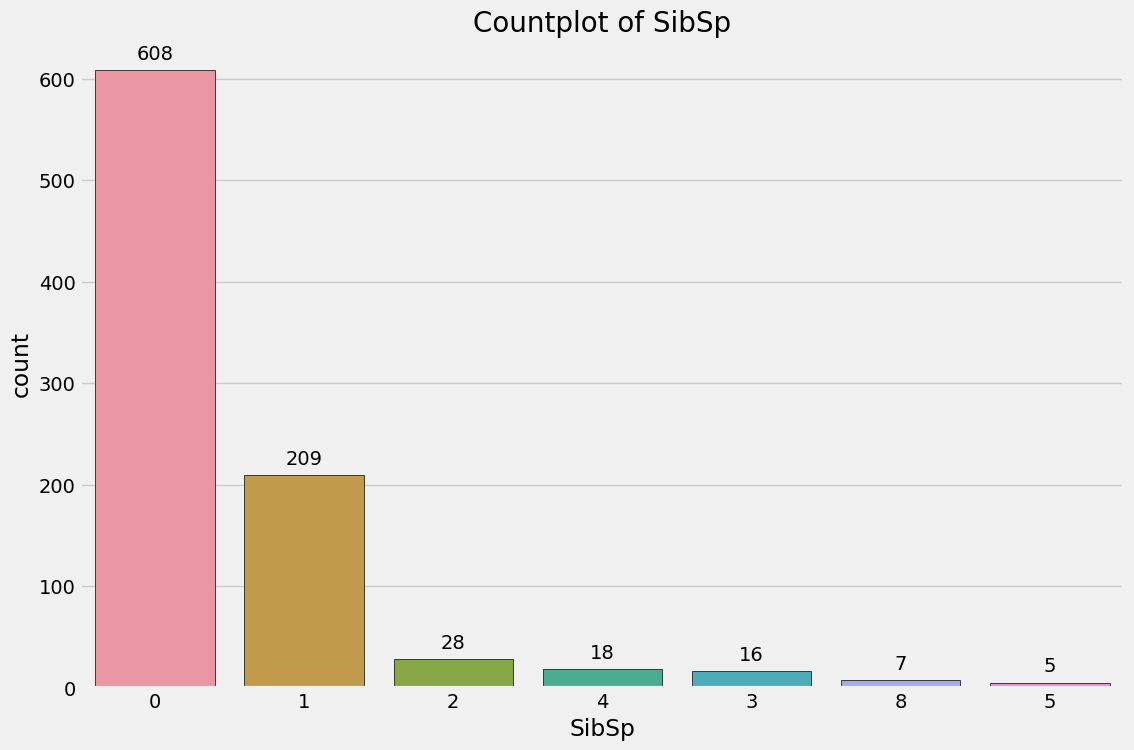

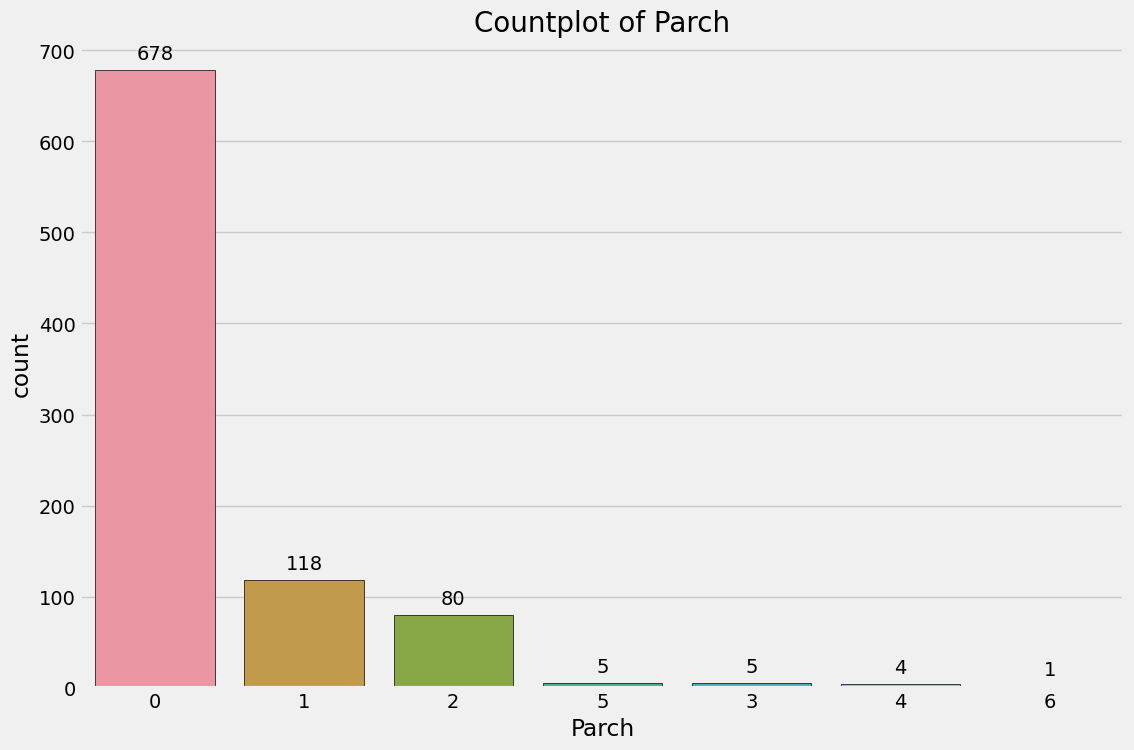

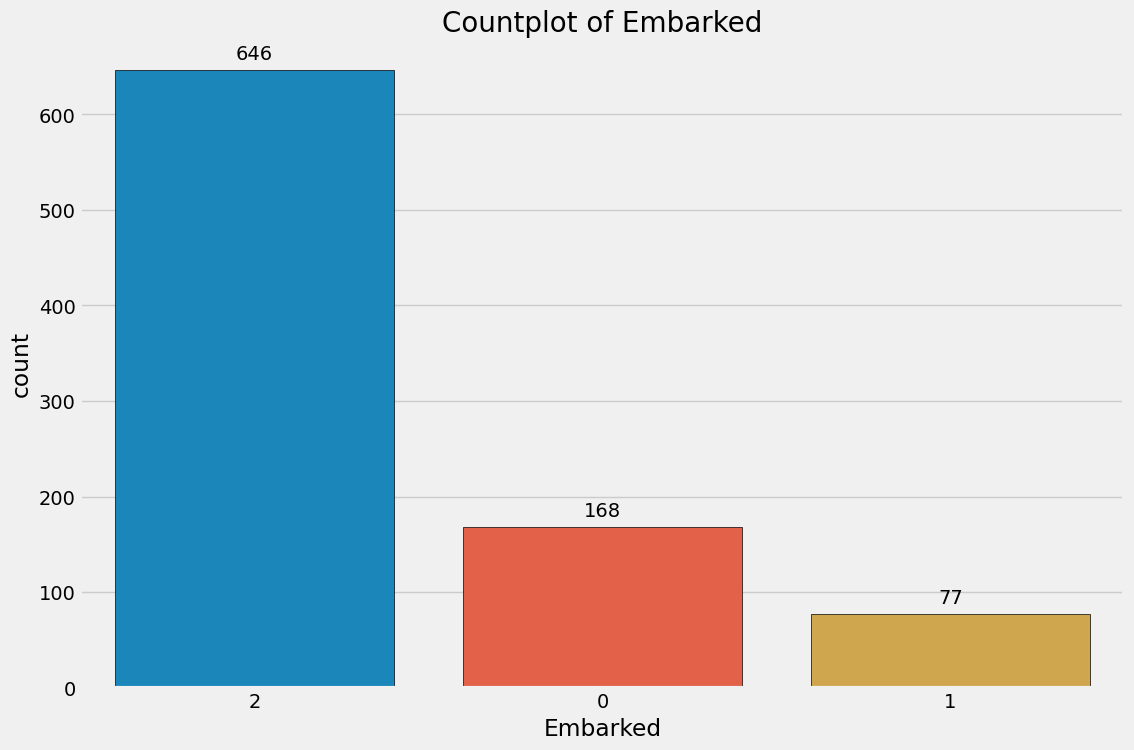

In [12]:
fast_eda(train_clean, target="Survived")

## Data Preprocessing

### Data Scaling and Normalization

In [13]:
train_clean['Age'] = train_clean['Age'].astype(int)
# Qcut is a quantile based discretization function to autimatically create categories (not used here)
# dataset['Age'] = pd.qcut(dataset['Age'], 6, labels=False)
# Using categories as defined above
train_clean.loc[ train_clean['Age'] <= 14, 'Age'] = 0
train_clean.loc[(train_clean['Age'] > 14) & (train_clean['Age'] <= 30), 'Age'] = 5
train_clean.loc[(train_clean['Age'] > 30) & (train_clean['Age'] <= 40), 'Age'] = 1
train_clean.loc[(train_clean['Age'] > 40) & (train_clean['Age'] <= 50), 'Age'] = 3
train_clean.loc[(train_clean['Age'] > 50) & (train_clean['Age'] <= 60), 'Age'] = 2
train_clean.loc[ train_clean['Age'] > 60, 'Age'] = 4
train_clean['Age'].value_counts()

Age
5    510
1    155
3     84
0     78
2     42
4     22
Name: count, dtype: int64

In [14]:
train_clean["Fare"] = train_clean["Fare"].map(lambda i: np.log(i) if i > 0 else 0)

In [15]:
train_clean.loc[train_clean['Fare'] <= 2.7, 'Fare'] = 0
#dataset.loc[(dataset['Fare'] > 2.7) & (dataset['Fare'] <= 3.2), 'Fare']   = 1
#dataset.loc[(dataset['Fare'] > 3.2) & (dataset['Fare'] <= 3.6), 'Fare']   = 2
train_clean.loc[train_clean['Fare'] > 2.7, 'Fare'] = 3
train_clean['Fare'] = train_clean['Fare'].astype(int)
train_clean['Fare'].value_counts()

Fare
0    457
3    434
Name: count, dtype: int64

In [16]:
train_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,5,1,0,523,0,47,2
1,2,1,1,190,0,1,1,0,596,3,81,0
2,3,1,3,353,0,5,0,0,669,0,47,2
3,4,1,1,272,0,1,1,0,49,3,55,2
4,5,0,3,15,1,1,0,0,472,0,47,2


In [17]:
train_clean.to_csv("titanic_clean.csv")

## Machine Learning Engineering

In [18]:
# Machine learning libraries
import xgboost as xgb  # Implementation of gradient boosted decision trees designed for speed and performance that is dominative competitive machine learning
import seaborn as sns  # Visualization library based on matplotlib, provides interface for drawing attractive statistical graphics

import sklearn         # Collection of machine learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, precision_recall_curve, confusion_matrix

In [19]:
X_train = train_clean.drop("Survived", axis=1)
Y_train = train_clean["Survived"]
X_train.shape, Y_train.shape, test.shape

from sklearn.model_selection import train_test_split
X_train, x_test, Y_train, y_test = train_test_split(X_train, Y_train, test_size=0.3, random_state=101)
X_test = test.copy() # test data for Kaggle submission

In [20]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, Y_train)
Y_pred1 = logreg.predict(x_test)
acc_log = round(logreg.score(x_test, y_test) * 100, 2)
acc_log

77.24

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, Y_pred1))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred1), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       154
           1       0.83      0.59      0.69       114

    accuracy                           0.77       268
   macro avg       0.79      0.75      0.75       268
weighted avg       0.78      0.77      0.76       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 140                   14
Actual: SURVIVED             47                   67


In [22]:
svc=SVC()
svc.fit(X_train, Y_train)
Y_pred2 = svc.predict(x_test)
acc_svc = round(svc.score(x_test, y_test) * 100, 2)
acc_svc

61.19

In [23]:
print(classification_report(y_test, Y_pred2))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred2), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.60      0.97      0.74       154
           1       0.75      0.13      0.22       114

    accuracy                           0.61       268
   macro avg       0.68      0.55      0.48       268
weighted avg       0.66      0.61      0.52       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 149                    5
Actual: SURVIVED             99                   15


In [24]:
knn = KNeighborsClassifier(algorithm='auto', leaf_size=26, metric='minkowski', 
                           metric_params=None, n_jobs=1, n_neighbors=10, p=2, 
                           weights='uniform')
knn.fit(X_train, Y_train)
knn_predictions = knn.predict(x_test)
acc_knn = round(knn.score(x_test, y_test) * 100, 2)
acc_knn

58.21

In [25]:
print(classification_report(y_test, knn_predictions))
cm = pd.DataFrame(confusion_matrix(y_test, knn_predictions), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.59      0.86      0.70       154
           1       0.52      0.20      0.29       114

    accuracy                           0.58       268
   macro avg       0.56      0.53      0.50       268
weighted avg       0.56      0.58      0.53       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 133                   21
Actual: SURVIVED             91                   23


[42, 0.6553398058252428]


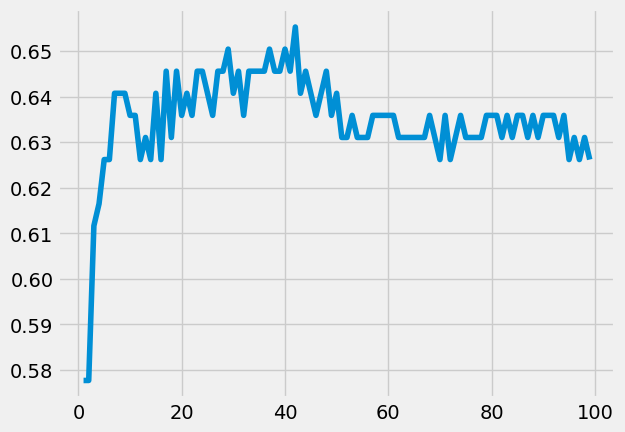

In [26]:
import matplotlib.pyplot as plt
## Selecting the right n_neighbors for the k-NN classifier
x_trainknn, x_testknn, y_trainknn, y_testknn = train_test_split(X_train,Y_train,test_size = .33, random_state = 0)
nn_scores = []
best_prediction = [-1,-1]
for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors=i, weights='distance', metric='minkowski', p =2)
    knn.fit(x_trainknn, y_trainknn)
    score = accuracy_score(y_testknn, knn.predict(x_testknn))
    #print i, score
    if score > best_prediction[1]:
        best_prediction = [i, score]
    nn_scores.append(score)
print (best_prediction)
plt.plot(range(1,100),nn_scores)

In [27]:
gaussian = GaussianNB()
gaussian.fit(X_train, Y_train)
Y_pred3 = gaussian.predict(x_test)
acc_gaussian = round(gaussian.score(x_test, y_test) * 100, 2)
acc_gaussian

75.75

In [28]:
print(classification_report(y_test, Y_pred3))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred3), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       154
           1       0.71      0.72      0.72       114

    accuracy                           0.76       268
   macro avg       0.75      0.75      0.75       268
weighted avg       0.76      0.76      0.76       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 121                   33
Actual: SURVIVED             32                   82


In [29]:
perceptron = Perceptron()
perceptron.fit(X_train, Y_train)
Y_pred4 = perceptron.predict(x_test)
acc_perceptron = round(perceptron.score(x_test, y_test) * 100, 2)
acc_perceptron

58.21

In [30]:
print(classification_report(y_test, Y_pred4))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred4), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.58      1.00      0.73       154
           1       1.00      0.02      0.03       114

    accuracy                           0.58       268
   macro avg       0.79      0.51      0.38       268
weighted avg       0.76      0.58      0.44       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 154                    0
Actual: SURVIVED            112                    2


In [31]:
linear_svc = LinearSVC()
linear_svc.fit(X_train, Y_train)
Y_pred5 = linear_svc.predict(x_test)
acc_linear_svc = round(linear_svc.score(x_test, y_test) * 100, 2)
acc_linear_svc

66.79

In [32]:
print(classification_report(y_test, Y_pred5))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred5), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.64      0.97      0.77       154
           1       0.88      0.25      0.39       114

    accuracy                           0.67       268
   macro avg       0.76      0.61      0.58       268
weighted avg       0.74      0.67      0.61       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 150                    4
Actual: SURVIVED             85                   29


In [33]:
sgd = SGDClassifier()
sgd.fit(X_train, Y_train)
Y_pred6 = sgd.predict(x_test)
acc_sgd = round(sgd.score(x_test, y_test) * 100, 2)
acc_sgd

42.54

In [34]:
print(classification_report(y_test, Y_pred6))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred6), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       154
           1       0.43      1.00      0.60       114

    accuracy                           0.43       268
   macro avg       0.21      0.50      0.30       268
weighted avg       0.18      0.43      0.25       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                   0                  154
Actual: SURVIVED              0                  114


In [35]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, Y_train)
Y_pred7 = decision_tree.predict(x_test)
acc_decision_tree = round(decision_tree.score(x_test, y_test) * 100, 2)
acc_decision_tree

80.97

In [36]:
print(classification_report(y_test, Y_pred7))
cm = pd.DataFrame(confusion_matrix(y_test, Y_pred7), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       154
           1       0.82      0.71      0.76       114

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 136                   18
Actual: SURVIVED             33                   81


In [37]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, Y_train)
random_forest_predictions = random_forest.predict(x_test)
acc_random_forest = round(random_forest.score(x_test, y_test) * 100, 2)
acc_random_forest

79.85

In [38]:
print(classification_report(y_test, random_forest_predictions))
cm = pd.DataFrame(confusion_matrix(y_test, random_forest_predictions), ['Actual: NOT', 'Actual: SURVIVED'], ['Predicted: NO', 'Predicted: SURVIVED'])
print(cm)

              precision    recall  f1-score   support

           0       0.77      0.93      0.84       154
           1       0.87      0.62      0.72       114

    accuracy                           0.80       268
   macro avg       0.82      0.78      0.78       268
weighted avg       0.81      0.80      0.79       268

                  Predicted: NO  Predicted: SURVIVED
Actual: NOT                 143                   11
Actual: SURVIVED             43                   71


## Model Summary

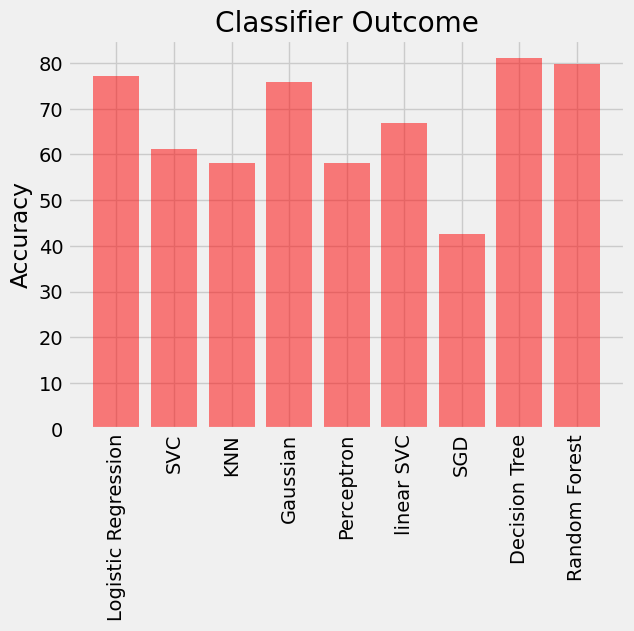

In [39]:
objects = ('Logistic Regression', 'SVC', 'KNN', 'Gaussian', 'Perceptron', 'linear SVC', 'SGD', 'Decision Tree', 'Random Forest')
x_pos = np.arange(len(objects))
accuracies1 = [acc_log, acc_svc, acc_knn, acc_gaussian, acc_perceptron, acc_linear_svc, acc_sgd, acc_decision_tree, acc_random_forest]
    
plt.bar(x_pos, accuracies1, align='center', alpha=0.5, color='r')
plt.xticks(x_pos, objects, rotation='vertical')
plt.ylabel('Accuracy')
plt.title('Classifier Outcome')
plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

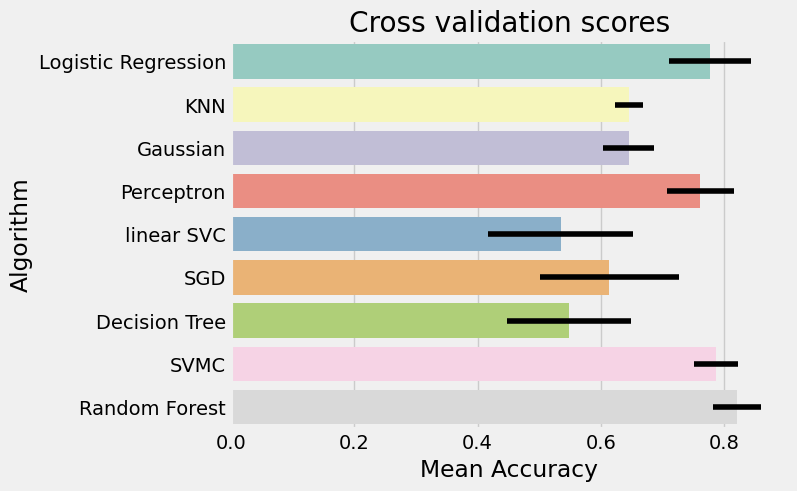

In [40]:
# Cross validate model with Kfold stratified cross validation
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=10)
# Modeling step Test differents algorithms 
random_state = 2

classifiers = []
classifiers.append(LogisticRegression(random_state = random_state))
classifiers.append(SVC(random_state=random_state))
classifiers.append(KNeighborsClassifier())
classifiers.append(GaussianNB())
classifiers.append(Perceptron(random_state=random_state))
classifiers.append(LinearSVC(random_state=random_state))
classifiers.append(SGDClassifier(random_state=random_state))
classifiers.append(DecisionTreeClassifier(random_state = random_state))
classifiers.append(RandomForestClassifier(random_state = random_state))

cv_results = []
for classifier in classifiers :
    cv_results.append(cross_val_score(classifier, X_train, y = Y_train, scoring = "accuracy", cv = kfold, n_jobs=4))

cv_means = []
cv_std = []
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

cv_res = pd.DataFrame({"CrossValMeans":cv_means,"CrossValerrors": cv_std,"Algorithm":['Logistic Regression',  'KNN', 'Gaussian',
    'Perceptron', 'linear SVC', 'SGD', 'Decision Tree','SVMC', 'Random Forest']})

g = sns.barplot(x = "CrossValMeans",y = "Algorithm",data = cv_res, palette="Set3",orient = "h",**{'xerr':cv_std})
g.set_xlabel("Mean Accuracy")
g = g.set_title("Cross validation scores")

### Yours Sincerely, Mr. Eslam Fouad.